<a href="https://colab.research.google.com/github/sournorm/-_4-8/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_2_2_%D0%97%D0%B0%D0%BF%D0%BE%D1%80%D0%BE%D0%B6%D0%B0%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 2.2
Виконав Запорожан Сергій ФІТ 4-8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

## Частина 1. Аналіз датасету Titanic

In [2]:
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(url_titanic)

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Розмір датасету:", titanic_df.shape)
print("\nПропущені значення ДО очищення:")
print(titanic_df.isnull().sum())

titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
titanic_df.drop(columns=['Cabin'], inplace=True)

print("\nПропущені значення ПІСЛЯ очищення:")
print(titanic_df.isnull().sum())

Розмір датасету: (891, 12)

Пропущені значення ДО очищення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Пропущені значення ПІСЛЯ очищення:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [4]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Частина 2. Коефіцієнт народжуваності в регіонах України

In [5]:
url_ukraine = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
response = requests.get(url_ukraine, headers=headers)

tables = pd.read_html(response.text)

for tbl in tables:
    if 'Регіон' in tbl.columns:
        birth_df = tbl
        break

birth_df.head()

/tmp/ipykernel_1840/1974263959.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—


In [6]:
birth_df = birth_df.replace("—", np.nan)

years_columns = birth_df.columns[1:]

for col in years_columns:
    birth_df[col] = birth_df[col].astype(str).str.replace(',', '.')
    birth_df[col] = pd.to_numeric(birth_df[col], errors='coerce')

birth_df = birth_df[birth_df['Регіон'] != 'Україна'].copy()

for col in years_columns:
    birth_df[col] = birth_df[col].fillna(birth_df[col].mean())

birth_df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,111.44,80.173913
1,Вінницька,224.0,192.0,142.0,124,84,112,109.00,76.000000
2,Волинська,247.0,250.0,179.0,153,112,148,141.00,101.000000
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111.00,71.000000
4,Донецька,271.0,214.0,140.0,109,61,98,82.00,80.173913


In [7]:
birth_df.describe()

,1950,1960,1970,1990,2000,2012,2014,2019
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,231.040000,207.576923,156.000000,130.592593,82.222222,116.555556,111.440000,80.173913
std,27.666253,29.356133,18.687717,15.544624,15.843789,16.667179,19.725189,13.640021
min,186.000000,163.000000,127.000000,108.000000,61.000000,94.000000,51.000000,60.000000
25%,212.000000,186.500000,144.000000,121.500000,70.500000,103.000000,103.500000,69.500000
50%,230.000000,204.000000,155.000000,126.000000,79.000000,115.000000,111.440000,80.000000
75%,245.000000,220.500000,163.000000,141.000000,90.000000,123.000000,121.000000,87.500000
max,314.000000,273.000000,207.000000,168.000000,118.000000,159.000000,148.000000,110.000000


## Частина 3. Побудова графіків

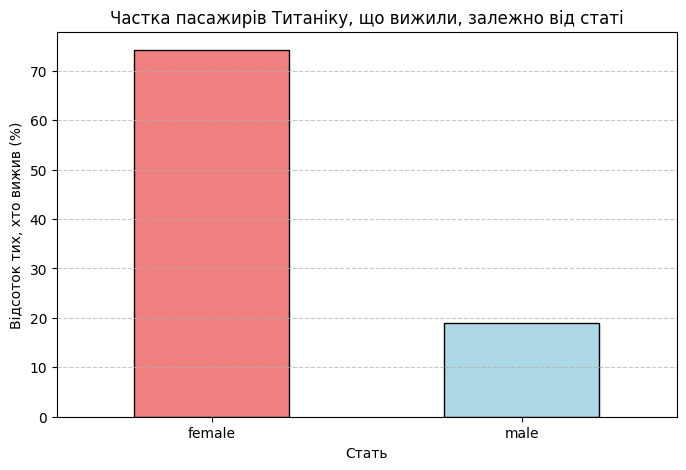

In [8]:
# Графік 1 (з датасету Titanic)
plt.figure(figsize=(8, 5))
survived_sex = titanic_df.groupby('Sex')['Survived'].mean() * 100
survived_sex.plot(kind='bar', color=['lightcoral', 'lightblue'], edgecolor='black')

plt.title('Частка пасажирів Титаніку, що вижили, залежно від статі')
plt.xlabel('Стать')
plt.ylabel('Відсоток тих, хто вижив (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

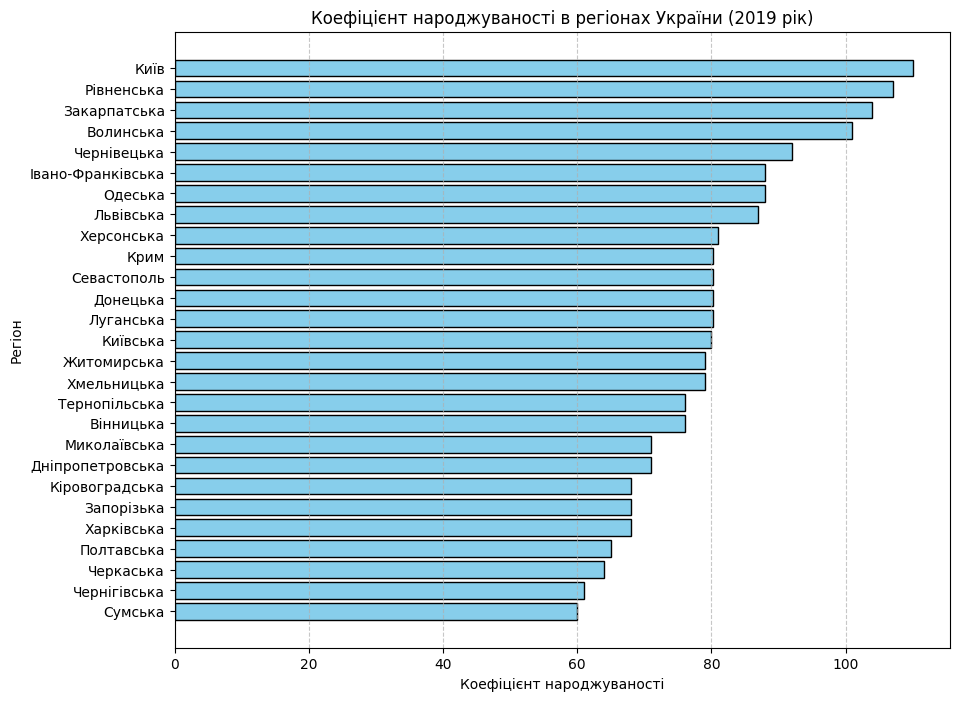

In [9]:
# Графік 2 (Україна)
sorted_2019 = birth_df.sort_values(by='2019', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(sorted_2019['Регіон'], sorted_2019['2019'], color='skyblue', edgecolor='black')

plt.title('Коефіцієнт народжуваності в регіонах України (2019 рік)')
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('Регіон')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

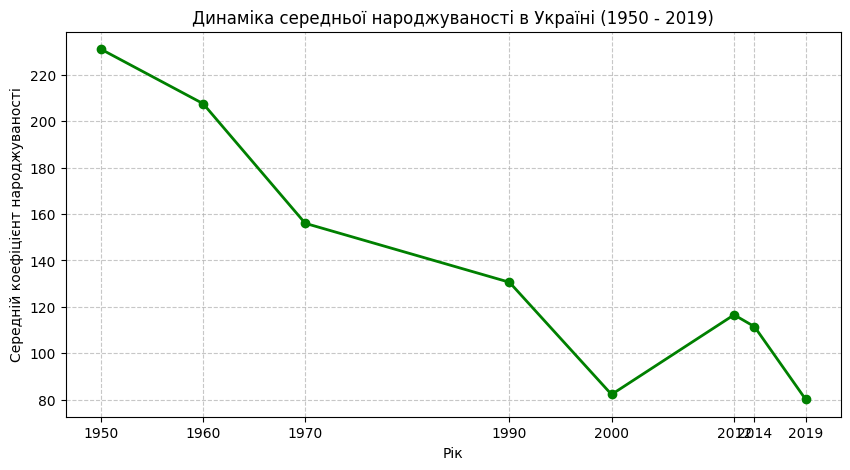

In [10]:
# Графік 3 (Україна): Динаміка народжуваності
years = years_columns.astype(int)
mean_birth_rates = birth_df[years_columns].mean()

plt.figure(figsize=(10, 5))
plt.plot(years, mean_birth_rates, marker='o', linestyle='-', color='green', linewidth=2)

plt.title('Динаміка середньої народжуваності в Україні (1950 - 2019)')
plt.xlabel('Рік')
plt.ylabel('Середній коефіцієнт народжуваності')
plt.xticks(years)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()